# Comparing the two approximate indexes : `SimHashIndexANN` and `SSHIndexANN`

In this notebook, we will compare the two approximate nearest neighbour (ANN) indexes of the whole-series similarity search module, `SimHashIndexANN` and `SSHIndexANN`, and work out which one to reach for. They hash very different things, so they fail in very different ways, and neither is simply better than the other : the answer depends on one property of your data that is easy to check.

For a general introduction to the module, see the [Time Series Similarity Search with aeon](similarity_search.ipynb) notebook. The mechanics of the SimHash index are covered in the [SimHash deep dive](simhash_index.ipynb), and how each index is tuned for recall against query speed is measured in the [performance notebook](code_speed.ipynb).

## What the two indexes hash

`SimHashIndexANN` projects the **whole series** onto random Gaussian vectors and keeps the sign of each projection. Two series collide on a given bit with probability exactly $1 - \theta/\pi$, where $\theta$ is the angle between them, which makes it a clean *locality-sensitive hash* for cosine similarity. It also makes it completely dependent on where a pattern sits : shift the series in time and its vector moves with it.

`SSHIndexANN` slides a short filter over the series and keeps one bit per position, then counts the $n$-grams of that bit string and hashes the resulting **multiset**. A multiset records *which* local patterns occurred and how often, not where they occurred, so the representation is largely unaffected by a time shift. What it hashes is the weighted Jaccard similarity of those multisets, which correlates empirically with DTW.

That difference in representation is the whole story of this notebook, and the sections below measure both of its sides.

## Both indexes re-rank, so the hash only chooses the candidates

A query probes one bucket per table and collects the union of what it finds : the **candidate set**. What happens next is a choice. `SSHIndexANN` always scores the candidates with a real distance, DTW by default. `SimHashIndexANN` ranks them by collision count unless you set `rerank_distance`, in which case it scores them the same way.

We give both indexes the same re-ranking distance below. That matters, because it isolates the only thing the two hashes actually control : **which series get scored at all**. Comparing a re-ranked index against a collision-ranked one would tell us about the ranking, not about the hashing.

It also fixes the axis to compare them on. Both indexes trade candidate-set size against recall, so a number of neighbours recovered is only meaningful next to the fraction of the collection that had to be scored to recover them. A *random* candidate set of fraction $p$ contains any given true neighbour with probability $p$, so the line recall $= p$ is what doing nothing achieves : a hash has to beat that diagonal to be worth its cost.

In [1]:
import warnings

import numpy as np
from matplotlib import pyplot as plt

from aeon.datasets import load_classification
from aeon.similarity_search.whole_series import (
    NaiveSeriesSearch,
    SimHashIndexANN,
    SSHIndexANN,
)
from aeon.utils.numba.general import z_normalise_series_2d

K = 5
X, _ = load_classification("ECG5000")
X = X[np.random.default_rng(0).permutation(len(X))]
queries, db = X[:20], X[20:2020]
print("collection shape :", db.shape)
print("queries shape    :", queries.shape)

collection shape : (2000, 1, 140)
queries shape    : (20, 1, 140)


The gold standard is an exhaustive DTW search over the same collection, so recall below always means *recall of the true DTW nearest neighbours*. We also read the size of the candidate set from `_gather_candidates`, a private method used here only to instrument the index -- `predict` gives no visibility into how many series it scored.

In [2]:
exact = NaiveSeriesSearch(normalize=True, distance="dtw", n_jobs=-1).fit(db)
gold = [set(exact.predict(q, k=K)[0]) for q in queries]


def recall_and_probe(index):
    """Return mean recall@K against exact DTW, and mean fraction of the db probed."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        index.fit(db)
        recalls, probed = [], []
        for query, truth in zip(queries, gold):
            neighbours, _ = index.predict(query, k=K)
            recalls.append(len(set(neighbours) & truth) / K)
            candidates, _ = index._gather_candidates(z_normalise_series_2d(query))
            probed.append(len(candidates) / len(db))
    return np.mean(recalls), np.mean(probed)

### Aligned queries : SimHash finds the better candidates

ECG5000 heartbeats are already aligned with one another, which is the ordinary situation for a collection of extracted, curated series. We sweep the selectivity of each index -- `n_bits_per_table` for SimHash, `n_hashes_per_table` for SSH -- so that each one traces out its own recall-against-probe curve, and both are re-ranked with DTW.

In [3]:
sweep = {
    "SimHashIndexANN": [
        SimHashIndexANN(
            n_tables=40, n_bits_per_table=b, rerank_distance="dtw", random_state=0
        )
        for b in (8, 12, 16, 20, 24)
    ],
    "SSHIndexANN": [
        SSHIndexANN(
            window_length=30,
            shift=2,
            shingle_size=15,
            n_tables=40,
            n_hashes_per_table=k,
            random_state=0,
        )
        for k in (2, 3, 4, 6, 8)
    ],
}
curves = {
    name: np.array([recall_and_probe(index) for index in indexes])
    for name, indexes in sweep.items()
}
for name, curve in curves.items():
    print(f"{name:16s} recall {np.round(curve[:, 0], 2)}")
    print(f"{'':16s} probed {np.round(curve[:, 1], 2)}")

SimHashIndexANN  recall [0.99 0.98 0.89 0.84 0.84]
                 probed [0.75 0.48 0.31 0.25 0.19]
SSHIndexANN      recall [0.9  0.91 0.76 0.52 0.41]
                 probed [0.83 0.65 0.43 0.2  0.1 ]


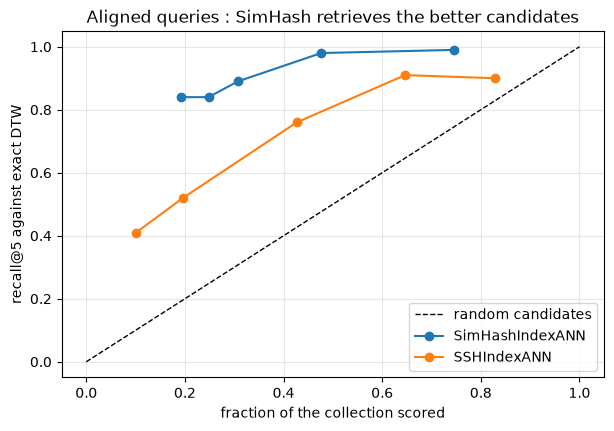

In [4]:
plt.figure(figsize=(7, 4.5))
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="random candidates")
for name, colour in (("SimHashIndexANN", "tab:blue"), ("SSHIndexANN", "tab:orange")):
    plt.plot(curves[name][:, 1], curves[name][:, 0], "o-", color=colour, label=name)
plt.xlabel("fraction of the collection scored")
plt.ylabel(f"recall@{K} against exact DTW")
plt.title("Aligned queries : SimHash retrieves the better candidates")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Both curves sit above the diagonal, so both hashes do something. But SimHash is above SSH everywhere, and the gap is wide : scoring around a fifth of the collection, it recovers most of the true DTW neighbours where SSH recovers roughly half of them.

This is worth sitting with, because the SSH representation is the one designed to correlate with DTW. The explanation is that the correlation is not the only thing that matters here. SSH earns its shift invariance by *discarding where a pattern occurs*, and when the collection is already aligned that information was not noise -- it was signal, and throwing it away costs more than the invariance returns. Cosine similarity on aligned heartbeats, coarse as it is about DTW, still puts the right series in the bucket.

### Misaligned queries : only the shingled index survives

Now we break the alignment. Each query is a *circularly shifted copy* of a series that is in the index, so the right answer is known without computing any gold standard, and rolling the series loses no information -- only its position changes.

We measure the hash directly here, as the fraction of the 40 tables in which the shifted query still lands in its source's bucket. That is the collision probability the LSH construction is built on, and it is comparable between the two indexes because both keep 40 tables. We report the probe fraction next to it, so that a high collision rate cannot be dismissed as simply having gathered more candidates.

In [5]:
shifts = [0, 2, 5, 10, 20]
sources = np.random.default_rng(1).choice(len(db), 60, replace=False)
shift_configs = {
    "SimHash k=8": SimHashIndexANN(n_tables=40, n_bits_per_table=8, random_state=0),
    "SimHash k=16": SimHashIndexANN(n_tables=40, n_bits_per_table=16, random_state=0),
    "SSH shift=2": SSHIndexANN(
        window_length=30,
        shift=2,
        shingle_size=15,
        n_tables=40,
        n_hashes_per_table=4,
        random_state=0,
    ),
    "SSH shift=1": SSHIndexANN(
        window_length=30,
        shift=1,
        shingle_size=15,
        n_tables=40,
        n_hashes_per_table=4,
        random_state=0,
    ),
}

collided, probed = {}, {}
for name, index in shift_configs.items():
    index.fit(db)
    collided[name], probed[name] = [], []
    for shift in shifts:
        rolled = np.roll(db[sources], shift, axis=2)
        tables, sizes = [], []
        for query, source in zip(rolled, sources):
            candidates, counts = index._gather_candidates(z_normalise_series_2d(query))
            hit = counts[candidates == source]
            tables.append(hit[0] / index.n_tables if len(hit) else 0.0)
            sizes.append(len(candidates) / len(db))
        collided[name].append(np.mean(tables))
        probed[name].append(np.mean(sizes))
    print(f"{name:13s} collision rate {np.round(collided[name], 2)}")

SimHash k=8   collision rate [1.   0.22 0.04 0.01 0.01]
SimHash k=16  collision rate [1.   0.05 0.   0.   0.  ]


SSH shift=2   collision rate [1.   0.82 0.32 0.4  0.17]


SSH shift=1   collision rate [1.   0.86 0.71 0.49 0.23]


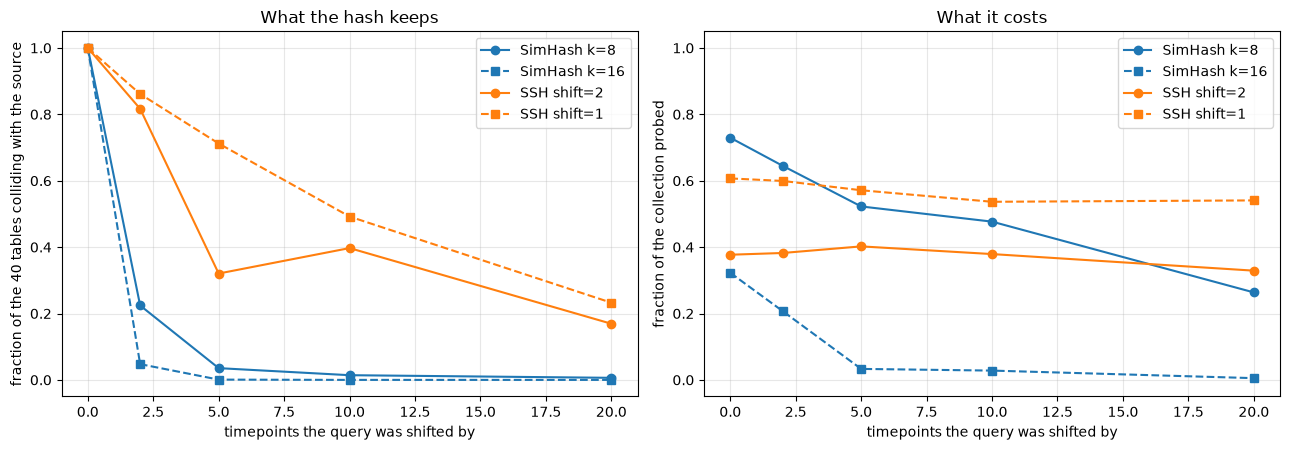

In [6]:
fig, (ax_hash, ax_cost) = plt.subplots(1, 2, figsize=(13, 4.6))
for name in shift_configs:
    colour = "tab:blue" if name.startswith("SimHash") else "tab:orange"
    style = "o-" if name.endswith(("8", "2")) else "s--"
    ax_hash.plot(shifts, collided[name], style, color=colour, label=name)
    ax_cost.plot(shifts, probed[name], style, color=colour, label=name)

ax_hash.set_ylabel("fraction of the 40 tables colliding with the source")
ax_hash.set_title("What the hash keeps")
ax_cost.set_ylabel("fraction of the collection probed")
ax_cost.set_title("What it costs")
for ax in (ax_hash, ax_cost):
    ax.set_xlabel("timepoints the query was shifted by")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The SimHash collision rate falls off a cliff : a shift of two timepoints out of 140 is already enough to lose most of it, and by ten it is gone. SSH still collides with its source at every shift tested -- a fifth of its tables even at 20 timepoints, and with $L = 40$ tables that is already enough for the source to reach the candidate set almost surely, since it is missed only when all 40 tables miss it at once. The right-hand panel shows it is not buying that with a bigger candidate set -- `SSH shift=2` sits near 0.4 throughout while `SimHash k=8` starts above 0.7. Note what the right-hand panel says about SimHash on its own : its candidate set *shrinks* as the query is displaced, which is not selectivity but the query drifting into an altogether different region of the hash space, where it collides with fewer and fewer series -- the wrong ones included.

The `shift` parameter ($\delta$, the step between two filter positions) shows up clearly. A query displaced by a multiple of $\delta$ puts the filter back on the same sample offsets, so its sketch is almost a translation of the original one, while a displacement that is not a multiple falls between filter positions. That is why `shift=2` dips at a 5-timepoint displacement and recovers at 10, whereas `shift=1` decays smoothly. **If you do not know the displacements in advance, use `shift=1`** and pay for the longer sketch.

One warning about measuring this end to end. It is tempting to score this experiment with `hit@k` on the output of `predict`, and it gives a much bleaker picture for both indexes -- but the fault then lies with the re-ranking, not with the hash. A DTW warping path is monotone, so it cannot wrap the end of a query round to its start, and a rolled heartbeat genuinely stops being its own DTW nearest neighbour. The index keeps offering the right series ; the distance declines to rank it first. **An invariance in the index survives only as far as the distance you re-rank with.**

## Which index should you use ?

| | `SimHashIndexANN` | `SSHIndexANN` |
|---|---|---|
| hashes | sign of a projection of the whole series | multiset of $n$-grams of a sliding sign sketch |
| exact for | cosine similarity, $1 - \theta/\pi$ per bit | weighted Jaccard of the shingle multisets |
| aligned collections | recovers most DTW neighbours from a fifth of the collection | needs to score far more for the same recall |
| shifted queries | collision rate collapses at a 2-timepoint shift | holds at every shift tested |
| ranking | collision count, or `rerank_distance` | always a real distance |
| cheapest query | yes, when `rerank_distance=None` : no distance is computed | no, every candidate is scored |
| selectivity dial | `n_bits_per_table` | `n_hashes_per_table` |

**Recommendation.** Ask whether the same pattern can appear at different offsets in your collection.

- If it cannot -- curated, aligned series, as in most classification archives -- use `SimHashIndexANN`. Leave `rerank_distance=None` when a rough neighbourhood is enough and you want the cheapest possible query, and set it to the distance you actually care about when you want the ordering to be right.
- If it can -- subsequences taken at arbitrary positions in a long series, events that are not aligned to a common origin -- use `SSHIndexANN` with `shift=1`. This is the setting the method was designed for, and no amount of loosening SimHash's buckets substitutes for it.
- If you are unsure, run the shifted-query experiment above on your own data. It needs no labels and no gold standard, only the ability to displace a query.

## Conclusion

We saw that the two indexes are not ordered by quality but by assumption : once both re-rank with the same distance, `SimHashIndexANN` retrieves better candidates on aligned collections, while `SSHIndexANN` is the only one of the two that still retrieves anything at all once the queries are displaced in time.

To go further :

- [Time Series Similarity Search with aeon](similarity_search.ipynb) for an introduction to the module and its other estimators ;
- [SimHash deep dive](simhash_index.ipynb) for the mechanics of the random projections, the $(k, L)$ amplification and the S-curve ;
- [Analysis of the speedups](code_speed.ipynb) for how to tune each index, and what its settings cost in recall and in query time.

### References

- M. S. Charikar, "Similarity estimation techniques from rounding algorithms", STOC 2002 (introduces SimHash as an LSH family for cosine similarity).
- P. Indyk and R. Motwani, "Approximate nearest neighbors : towards removing the curse of dimensionality", STOC 1998 (the multi-table $(k, L)$ scheme).
- C. Luo and A. Shrivastava, "SSH (Sketch, Shingle, & Hash) for Indexing Massive-Scale Time Series", arXiv:1610.07328, 2016 (the SSH index).
- A. Z. Broder, S. C. Glassman, M. S. Manasse and G. Zweig, "Syntactic clustering of the web", WWW 1997 (MinHash for set similarity).